<a href="https://colab.research.google.com/github/Tolureis/CMPE-403-Fundamentals-of-Image-Processing/blob/main/Morphological_Image_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

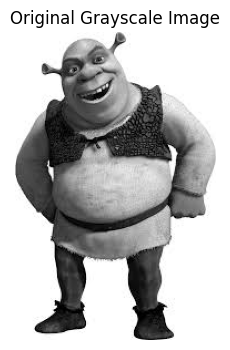

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# If the file cannot be found, a synthetic sample image will be created.
image_path = '/content/shrek.jpg'  # Change this value to the path of your own image

# Read the image as grayscale
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    print("The selected image could not be read. A synthetic example is being generated...")
    # Create a white 'J' on a 200x200 black background
    image = np.zeros((200, 200), dtype=np.uint8)
    cv2.putText(image, 'J', (50, 150), cv2.FONT_HERSHEY_SIMPLEX, 5, 255, 20, cv2.LINE_AA)

# Display the image using matplotlib
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')
plt.show()


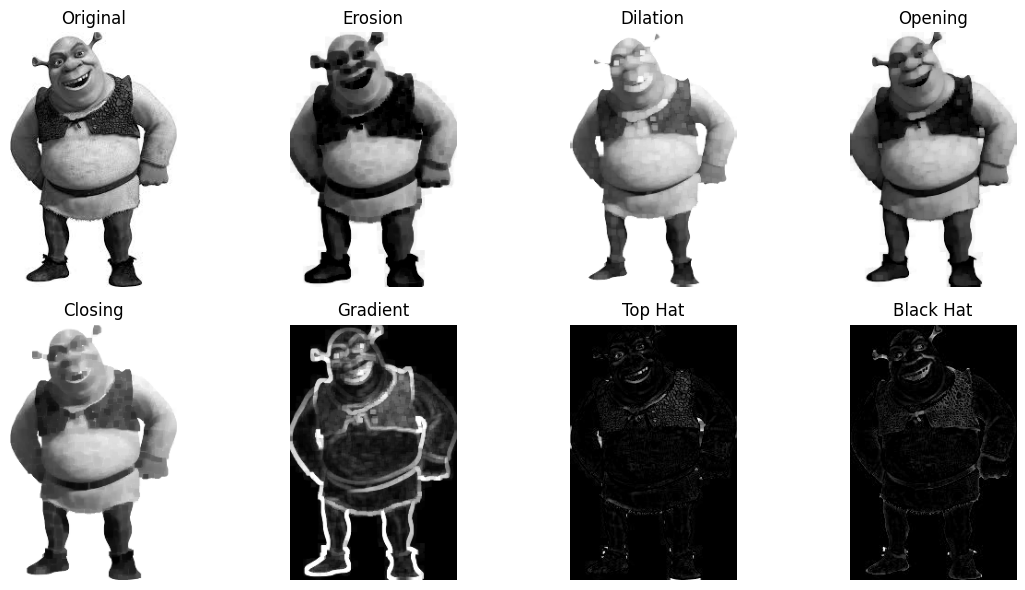

In [ ]:

# Define a 5x5 kernel of ones
kernel = np.ones((5, 5), np.uint8)

# Erosion
erosion = cv2.erode(image, kernel, iterations=1)

# Dilation
dilation = cv2.dilate(image, kernel, iterations=1)

# Opening (Erosion followed by Dilation)
opening = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)

# Closing (Dilation followed by Erosion)
closing = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)

# Morphological Gradient (Dilation - Erosion)
gradient = cv2.morphologyEx(image, cv2.MORPH_GRADIENT, kernel)

# Top Hat (Input image - Opening)
tophat = cv2.morphologyEx(image, cv2.MORPH_TOPHAT, kernel)

# Black Hat (Closing - Input image)
blackhat = cv2.morphologyEx(image, cv2.MORPH_BLACKHAT, kernel)

# Visualize the results
images = [image, erosion, dilation, opening, closing, gradient, tophat, blackhat]
titles = ['Original', 'Erosion', 'Dilation', 'Opening', 'Closing', 'Gradient', 'Top Hat', 'Black Hat']

plt.figure(figsize=(12, 6))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()


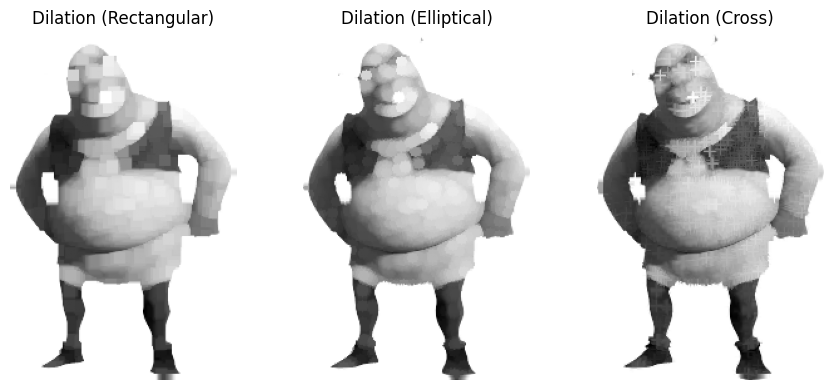

In [ ]:

# Define structuring elements of different shapes
kernel_rect = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
kernel_ellipse = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
kernel_cross = cv2.getStructuringElement(cv2.MORPH_CROSS, (9, 9))

kernels = [kernel_rect, kernel_ellipse, kernel_cross]
kernel_names = ['Rectangular', 'Elliptical', 'Cross']

# Show dilation for each kernel
plt.figure(figsize=(9, 4))
for i, (k, name) in enumerate(zip(kernels, kernel_names)):
    dilated = cv2.dilate(image, k, iterations=1)
    plt.subplot(1, 3, i + 1)
    plt.imshow(dilated, cmap='gray')
    plt.title(f'Dilation ({name})')
    plt.axis('off')
plt.tight_layout()
plt.show()
